In [2]:
import pandas as pd

df = pd.read_excel("../data/sales.xlsx")

print(df.head())

        State                 Date        Total   Category
0     Alabama  2019-01-12 00:00:00  109574036.0  Beverages
1     Arizona  2019-01-12 00:00:00  109101594.6  Beverages
2    Arkansas  2019-01-12 00:00:00   58049432.2  Beverages
3  California  2019-01-12 00:00:00  444766890.6  Beverages
4    Colorado  2019-01-12 00:00:00   89816716.3  Beverages


In [3]:
print(df.columns)

Index(['State', 'Date', 'Total', 'Category'], dtype='object')


In [4]:
print(df.isnull().sum())

State       0
Date        0
Total       0
Category    0
dtype: int64


In [5]:
print(df.dtypes)

State        object
Date         object
Total       float64
Category     object
dtype: object


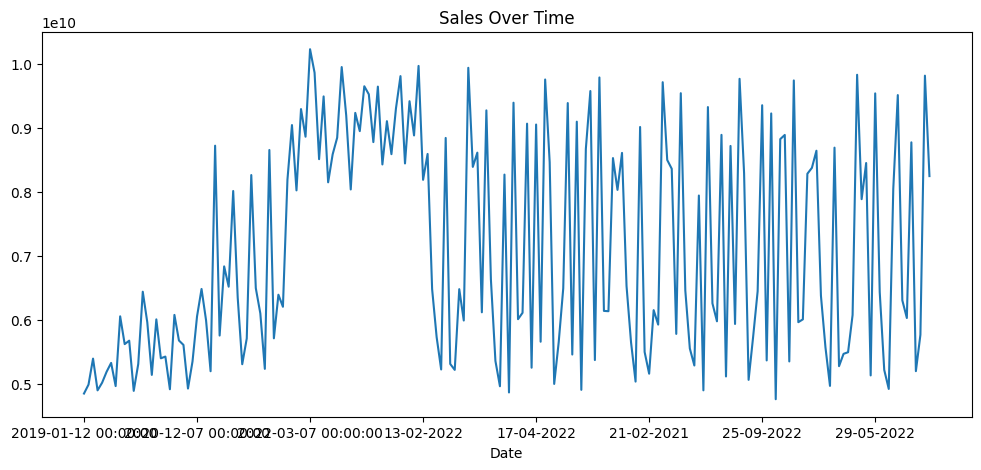

In [7]:
import matplotlib.pyplot as plt

df.groupby('Date')['Total'].sum().plot(figsize=(12,5))

plt.title("Sales Over Time")
plt.show()

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

print(df.dtypes)


State               object
Date        datetime64[ns]
Total              float64
Category            object
dtype: object


In [9]:
df = df.sort_values('Date')

df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12,109574036.0,Beverages
24,New Mexico,2019-01-12,34731555.3,Beverages
25,New York,2019-01-12,240815212.2,Beverages
26,North Carolina,2019-01-12,182341458.0,Beverages
27,Ohio,2019-01-12,194452564.4,Beverages


In [10]:
print(df['Date'].min())
print(df['Date'].max())

2019-01-12 00:00:00
2023-12-03 00:00:00


In [11]:
weekly_sales = df.groupby(['State', 'Date'])['Total'].sum().reset_index()

weekly_sales.head()

,State,Date,Total
0,Alabama,2019-01-12,109574036.0
1,Alabama,2019-03-11,112189103.8
2,Alabama,2019-06-10,129106730.4
3,Alabama,2019-08-12,108083723.8
4,Alabama,2019-10-11,110932912.8


In [12]:
state_df = weekly_sales[weekly_sales['State'] == 'California']

In [14]:
state_df = state_df.asfreq('W')

In [15]:
state_df['Total'] = state_df['Total'].fillna(method='ffill')

C:\Users\pavie\AppData\Local\Temp\ipykernel_7612\4196404382.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  state_df['Total'] = state_df['Total'].fillna(method='ffill')


In [16]:
print(state_df.isnull().sum())

State    131
Total     39
dtype: int64


In [17]:
state_df['State'] = state_df['State'].fillna('California')

In [18]:
state_df['Total'] = state_df['Total'].ffill()

In [19]:
print(state_df.isnull().sum())

State     0
Total    39
dtype: int64


In [20]:
state_df['Total'] = state_df['Total'].bfill()

In [21]:
print(state_df.isnull().sum())

State    0
Total    0
dtype: int64


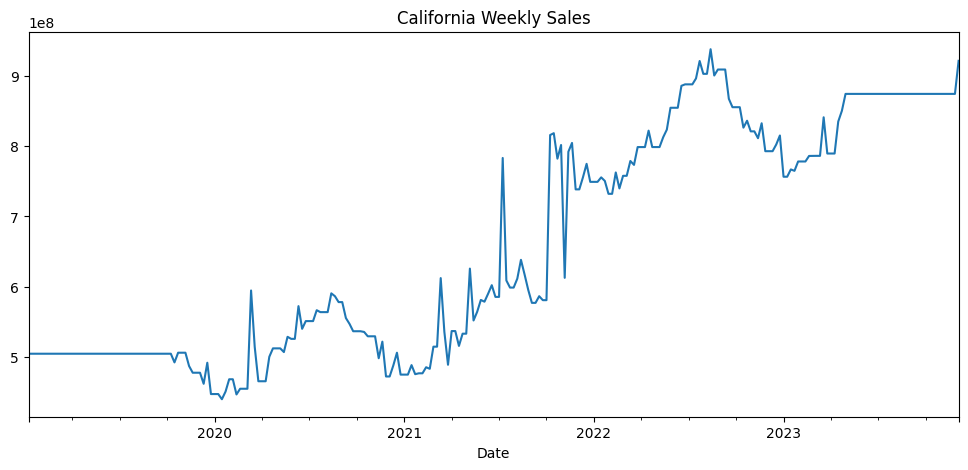

In [22]:
import matplotlib.pyplot as plt

state_df['Total'].plot(figsize=(12,5))

plt.title("California Weekly Sales")
plt.show()

In [23]:
train_size = int(len(state_df) * 0.8)

train = state_df[:train_size]
test = state_df[train_size:]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (204, 2)
Test Shape: (52, 2)


In [24]:
state_df.head()

,State,Total
Date,,
2019-01-13,California,504318965.7
2019-01-20,California,504318965.7
2019-01-27,California,504318965.7
2019-02-03,California,504318965.7
2019-02-10,California,504318965.7


In [25]:
state_df['lag_1'] = state_df['Total'].shift(1)

state_df['lag_7'] = state_df['Total'].shift(7)

state_df['lag_30'] = state_df['Total'].shift(30)

In [26]:
state_df['rolling_mean_7'] = state_df['Total'].rolling(window=7).mean()

In [28]:
state_df['rolling_std_7'] = state_df['Total'].rolling(window=7).std()

In [29]:
state_df['month'] = state_df.index.month

state_df['quarter'] = state_df.index.quarter

state_df['year'] = state_df.index.year

In [30]:
state_df['week_of_year'] = state_df.index.isocalendar().week

In [31]:
state_df.head(15)

,State,Total,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,month,quarter,year,week_of_year
Date,,,,,,,,,,,
2019-01-13,California,504318965.7,NaN,NaN,NaN,NaN,NaN,1,1,2019,2
2019-01-20,California,504318965.7,504318965.7,NaN,NaN,NaN,NaN,1,1,2019,3
2019-01-27,California,504318965.7,504318965.7,NaN,NaN,NaN,NaN,1,1,2019,4
2019-02-03,California,504318965.7,504318965.7,NaN,NaN,NaN,NaN,2,1,2019,5
2019-02-10,California,504318965.7,504318965.7,NaN,NaN,NaN,NaN,2,1,2019,6
2019-02-17,California,504318965.7,504318965.7,NaN,NaN,NaN,NaN,2,1,2019,7
2019-02-24,California,504318965.7,504318965.7,NaN,NaN,504318965.7,0.0,2,1,2019,8
2019-03-03,California,504318965.7,504318965.7,504318965.7,NaN,504318965.7,0.0,3,1,2019,9
2019-03-10,California,504318965.7,504318965.7,504318965.7,NaN,504318965.7,0.0,3,1,2019,10


In [32]:
state_df = state_df.dropna()

In [33]:
print(state_df.isnull().sum())

State             0
Total             0
lag_1             0
lag_7             0
lag_30            0
rolling_mean_7    0
rolling_std_7     0
month             0
quarter           0
year              0
week_of_year      0
dtype: int64


In [34]:
X = state_df.drop(['Total', 'State'], axis=1)

y = state_df['Total']

In [35]:
split = int(len(state_df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [36]:
print(X_train.shape)
print(X_test.shape)

(180, 9)
(46, 9)


In [37]:
from statsmodels.tsa.arima.model import ARIMA

In [38]:
arima_model = ARIMA(train['Total'], order=(5,1,0))

arima_result = arima_model.fit()

In [39]:
arima_forecast = arima_result.forecast(steps=len(test))

print(arima_forecast.head())

2022-12-11    7.983179e+08
2022-12-18    7.967895e+08
2022-12-25    8.004544e+08
2023-01-01    7.976007e+08
2023-01-08    7.973972e+08
Freq: W-SUN, Name: predicted_mean, dtype: float64


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [41]:
arima_mae = mean_absolute_error(test['Total'], arima_forecast)

arima_rmse = np.sqrt(mean_squared_error(test['Total'], arima_forecast))

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 56493766.72656177
ARIMA RMSE: 63772886.70862284


In [42]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [43]:
prophet_df = state_df.reset_index()[['Date', 'Total']]

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2019-08-11,504318965.7
1,2019-08-18,504318965.7
2,2019-08-25,504318965.7
3,2019-09-01,504318965.7
4,2019-09-08,504318965.7


In [44]:
split = int(len(prophet_df) * 0.8)

prophet_train = prophet_df[:split]

prophet_test = prophet_df[split:]

In [45]:
prophet_model = Prophet()

prophet_model.fit(prophet_train)

10:51:01 - cmdstanpy - INFO - Chain [1] start processing
10:51:02 - cmdstanpy - INFO - Chain [1] done processing


In [46]:
future = prophet_model.make_future_dataframe(
    periods=len(prophet_test),
    freq='W'
)

forecast = prophet_model.predict(future)

In [47]:
forecast[['ds', 'yhat']].tail()

,ds,yhat
221,2023-11-05,8.872961e+08
222,2023-11-12,8.817295e+08
223,2023-11-19,8.798794e+08
224,2023-11-26,8.750598e+08
225,2023-12-03,8.669537e+08


In [48]:
prophet_predictions = forecast['yhat'][-len(prophet_test):].values

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

prophet_mae = mean_absolute_error(
    prophet_test['y'],
    prophet_predictions
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_test['y'],
        prophet_predictions
    )
)

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)

Prophet MAE: 26259057.04383137
Prophet RMSE: 31420979.117710795


In [51]:
from xgboost import XGBRegressor

In [53]:
xgb_predictions = xgb_model.predict(X_test)

In [54]:
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 20932843.55869565
XGBoost RMSE: 25160521.777776826


In [55]:
results = {
    "ARIMA": arima_mae,
    "Prophet": prophet_mae,
    "XGBoost": xgb_mae
}

print(results)

{'ARIMA': 56493766.72656177, 'Prophet': 26259057.04383137, 'XGBoost': 20932843.55869565}


In [56]:
best_model = min(results, key=results.get)

print("Best Model:", best_model)

Best Model: XGBoost


In [57]:
import joblib

joblib.dump(xgb_model, "../models/best_model.pkl")

['../models/best_model.pkl']

In [52]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
state_df = state_df.set_index('Date')

state_df.head()

,State,Total
Date,,
2019-01-12,California,444766890.6
2019-03-11,California,492597099.4
2019-06-10,California,506587724.1
2019-08-12,California,449865324.4
2019-10-11,California,497063951.7
